# Level 5 Sensitivity Analysis: Full System (30 Parameters)

Morris screening + Sobol analysis across all L1–L4 bulk transport parameters.
- **Level 1**: Metal diffusivity & solubility (Arrhenius)
- **Level 2**: Oxide barrier properties
- **Level 3**: Oxide defect paths
- **Level 4**: Metal microstructure (grain boundaries + trapping)

**Workflow:** Run Morris (500 trajectories, 30 params) → rank → focused Sobol on top 10.

In [1]:
from SALib.sample import morris as morris_sampler
from SALib.analyze import morris as morris_analyzer
from SALib.plotting import morris as morris_plotter
from SALib.sample import saltelli as sobol_sampler
from SALib.analyze import sobol as sobol_analyzer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys


# Add parent directory to path
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
# =============================================================================
# LEVEL 5 SENSITIVITY ANALYSIS SETUP
# =============================================================================

from validation.sensitivity_level1 import (
    morris_sensitivity_level5,
    sobol_sensitivity_level5,
    plot_morris_results,
    plot_sobol_results,
    SUGGESTED_RANGES_LEVEL5,
    DEFAULT_PARAMS_LEVEL5,
    VALID_OUTPUT_METRICS_L5
)

# Check what we have
print(f"Number of parameters in SUGGESTED_RANGES_LEVEL5: {len(SUGGESTED_RANGES_LEVEL5)}")
print(f"\nParameters:")
for i, (param, bounds) in enumerate(SUGGESTED_RANGES_LEVEL5.items(), 1):
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]")

print(f"\nValid output metrics: {VALID_OUTPUT_METRICS_L5}")

Number of parameters in SUGGESTED_RANGES_LEVEL5: 30

Parameters:
   1. D_ref                    : [4.28e-11, 4.29e-07]
   2. E_D                      : [6.00e+04, 8.00e+04]
   3. K_s_ref                  : [1.00e-04, 1.00e-01]
   4. H_s                      : [1.00e+03, 5.00e+04]
   5. T_ref_metal              : [6.00e+02, 1.40e+03]
   6. D_ox_ref                 : [7.80e-21, 7.80e-17]
   7. E_D_ox                   : [6.90e+04, 7.10e+04]
   8. K_ox_ref                 : [8.00e-02, 4.00e-01]
   9. H_sol_ox                 : [2.00e+04, 1.70e+05]
  10. T_ref_oxide              : [6.00e+02, 1.40e+03]
  11. metal_thickness          : [5.00e-04, 5.00e-03]
  12. oxide_thickness          : [1.00e-10, 1.00e-05]
  13. P_upstream               : [1.00e-07, 1.00e+07]
  14. f_pinhole                : [1.00e-05, 1.00e-01]
  15. f_crack                  : [1.00e-05, 1.00e-01]
  16. f_gb_defect              : [1.00e-05, 1.00e-01]
  17. crack_thickness_factor   : [1.00e-02, 5.00e-01]
  18. gb_diffusiv

In [3]:
# =============================================================================
# SETUP - RUN ONCE AFTER KERNEL RESTART
# =============================================================================
import numpy as np
import random
import importlib

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Force reload of modules
import validation.sensitivity_level1 as sens_module
importlib.reload(sens_module)

# Import everything needed
from validation.sensitivity_level1 import (
    morris_sensitivity_level5,
    sobol_sensitivity_level5,
    plot_morris_results,
    plot_sobol_results,
    SUGGESTED_RANGES_LEVEL5,
    DEFAULT_PARAMS_LEVEL5,
    VALID_OUTPUT_METRICS_L5
)

print("✓ Setup complete")
print(f"  Parameters: {len(SUGGESTED_RANGES_LEVEL5)}")
print(f"  Output metrics: {VALID_OUTPUT_METRICS_L5}")

✓ Setup complete
  Parameters: 30
  Output metrics: ['flux', 'permeability']


In [4]:
# =============================================================================
# MORRIS ANALYSIS: ALL VALID OUTPUT METRICS
# =============================================================================
# Run Morris screening for each output metric and store results

morris_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'#'*70}")
    print(f"# Running Morris for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = morris_sensitivity_level5(
        SUGGESTED_RANGES_LEVEL5,
        N_trajectories=500,
        num_levels=4,
        seed=42,
        output_metric=output_metric
        
    )
    
    morris_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }
    
print("\n" + "="*70)
print("✓ Morris analysis complete for all output metrics!")
print("="*70)


######################################################################
# Running Morris for: flux
######################################################################

MORRIS SENSITIVITY ANALYSIS - LEVEL 5 (Complete Hierarchical Model)
Running 15500 Morris samples...
Parameters (30): D_ref, E_D, K_s_ref, H_s, T_ref_metal, D_ox_ref, E_D_ox, K_ox_ref, H_sol_ox, T_ref_oxide, metal_thickness, oxide_thickness, P_upstream, f_pinhole, f_crack, f_gb_defect, crack_thickness_factor, gb_diffusivity_factor, grain_size, gb_thickness, lattice_density, trap_dislocation_E_b, trap_dislocation_N_T, trap_gb_E_b, trap_gb_N_T, trap_vacancy_E_b, trap_vacancy_N_T, trap_carbide_E_b, trap_carbide_N_T, temperature
Output metric: flux



/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1951: UserWarning: GB traps already in trap_list, not adding automatically
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 806.3 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "


  Completed 10/15500 samples
  Completed 20/15500 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 5.27e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "


  Completed 30/15500 samples
  Completed 40/15500 samples


...

  Completed 15140/15500 samples
  Completed 15150/15500 samples
  Completed 15160/15500 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 6.47e-04 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "


  Completed 15170/15500 samples
  Completed 15180/15500 samples
  Completed 15190/15500 samples
  Completed 15200/15500 samples
  Completed 15210/15500 samples
  Completed 15220/15500 samples
  Completed 15230/15500 samples
  Completed 15240/15500 samples
  Completed 15250/15500 samples
  Completed 15260/15500 samples
  Completed 15270/15500 samples
  Completed 15280/15500 samples
  Completed 15290/15500 samples
  Completed 15300/15500 samples
  Completed 15310/15500 samples
  Completed 15320/15500 samples
  Completed 15330/15500 samples
  Completed 15340/15500 samples
  Completed 15350/15500 samples
  Completed 15360/15500 samples
  Completed 15370/15500 samples
  Completed 15380/15500 samples
  Completed 15390/15500 samples
  Completed 15400/15500 samples
  Completed 15410/15500 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 6.24e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "


  Completed 15420/15500 samples
  Completed 15430/15500 samples
  Completed 15440/15500 samples
  Completed 15450/15500 samples
  Completed 15460/15500 samples
  Completed 15470/15500 samples
  Completed 15480/15500 samples
  Completed 15490/15500 samples
  Completed 15500/15500 samples

✓ Morris analysis complete
  Output range: [5.11e-26, 2.01e+12]
  Output span: 39421170889398146252221009446997852160.0× variation

  Top 10 most influential parameters:
    1. H_sol_ox: μ = 8.92e+09
    2. gb_diffusivity_factor: μ = 2.79e+09
    3. temperature: μ = 1.13e+09
    4. oxide_thickness: μ = -9.91e+08
    5. E_D_ox: μ = 8.92e+08
    6. T_ref_oxide: μ = -4.93e+08
    7. K_ox_ref: μ = 3.71e+08
    8. D_ox_ref: μ = 1.88e+08
    9. crack_thickness_factor: μ = -1.77e+08
    10. f_crack: μ = 1.72e+08

######################################################################
# Running Morris for: permeability
######################################################################

MORRIS SENSITIVITY AN

In [5]:
morris_results

{'flux': {'Si': {'names': array(['D_ref', 'E_D', 'K_s_ref', 'H_s', 'T_ref_metal', 'D_ox_ref',
          'E_D_ox', 'K_ox_ref', 'H_sol_ox', 'T_ref_oxide', 'metal_thickness',
          'oxide_thickness', 'P_upstream', 'f_pinhole', 'f_crack',
          'f_gb_defect', 'crack_thickness_factor', 'gb_diffusivity_factor',
          'grain_size', 'gb_thickness', 'lattice_density',
          'trap_dislocation_E_b', 'trap_dislocation_N_T', 'trap_gb_E_b',
          'trap_gb_N_T', 'trap_vacancy_E_b', 'trap_vacancy_N_T',
          'trap_carbide_E_b', 'trap_carbide_N_T', 'temperature'],
         dtype='<U22'),
   'mu': masked_array(data=[-21381.603917317247, -200.1697122399256,
                      -43757.70396547356, 198.12789245286285,
                      68347.41726504678, 187953656.0458852,
                      891788548.9066813, 371450295.5320597,
                      8916565337.880533, -492628475.6865271,
                      1054.5229393785648, -990652192.7705646,
                      36


OUTPUT: flux


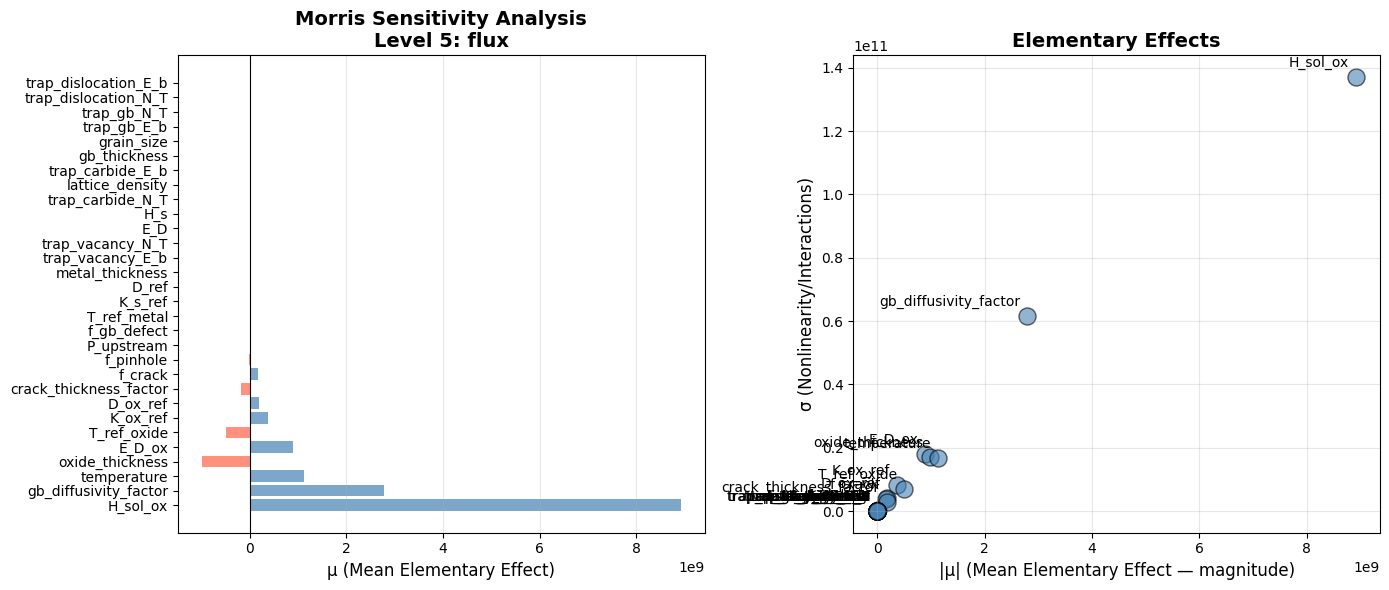


MORRIS SENSITIVITY RESULTS - Level 5: flux
             Parameter             μ            σ       μ_conf
              H_sol_ox  8.916565e+09 1.370594e+11 1.317234e+10
 gb_diffusivity_factor  2.788835e+09 6.145214e+10 5.728567e+09
           temperature  1.125488e+09 1.665369e+10 1.545789e+09
       oxide_thickness -9.906522e+08 1.711290e+10 1.272004e+09
                E_D_ox  8.917885e+08 1.792351e+10 1.706125e+09
           T_ref_oxide -4.926285e+08 6.816926e+09 5.766663e+08
              K_ox_ref  3.714503e+08 8.301047e+09 6.912784e+08
              D_ox_ref  1.879537e+08 4.193962e+09 3.855622e+08
crack_thickness_factor -1.767271e+08 2.937767e+09 2.381500e+08
               f_crack  1.721073e+08 3.841595e+09 2.921471e+08
             f_pinhole -1.104099e+07 2.442388e+08 2.017929e+07
            P_upstream  3.677993e+06 7.398219e+07 5.796827e+06
           f_gb_defect  2.294655e+06 4.196242e+07 3.436149e+06
           T_ref_metal  6.834742e+04 8.752854e+05 7.523054e+04
           

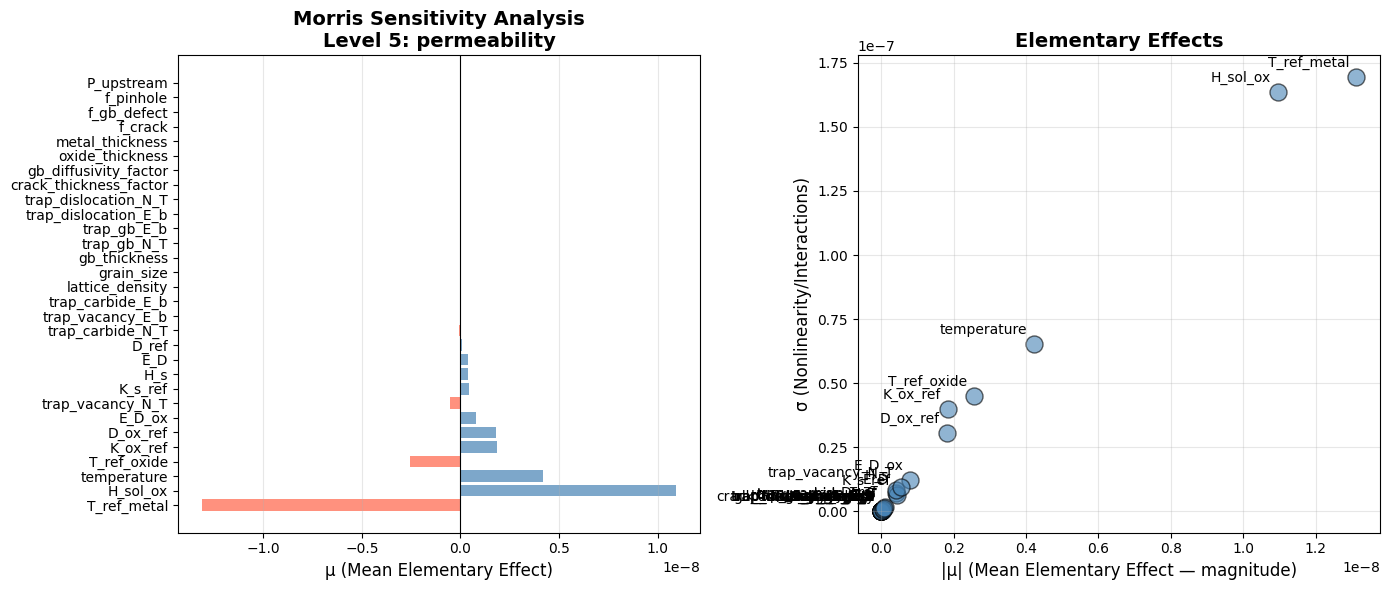


MORRIS SENSITIVITY RESULTS - Level 5: permeability
             Parameter             μ            σ       μ_conf
           T_ref_metal -1.312667e-08 1.695139e-07 1.602852e-08
              H_sol_ox  1.095635e-08 1.638157e-07 1.609788e-08
           temperature  4.205704e-09 6.509453e-08 6.081915e-09
           T_ref_oxide -2.560491e-09 4.508156e-08 3.751691e-09
              K_ox_ref  1.849728e-09 3.990602e-08 3.711797e-09
              D_ox_ref  1.815469e-09 3.055922e-08 2.604502e-09
                E_D_ox  7.870572e-10 1.222102e-08 1.080825e-09
      trap_vacancy_N_T -5.324660e-10 9.488156e-09 8.635053e-10
               K_s_ref  4.408566e-10 6.351796e-09 5.479082e-10
                   H_s  4.013115e-10 8.346927e-09 6.488869e-10
                   E_D  4.001119e-10 6.860924e-09 6.939264e-10
                 D_ref  9.180599e-11 1.397884e-09 1.143607e-10
      trap_carbide_N_T -7.539367e-11 1.228587e-09 9.342504e-11
      trap_vacancy_E_b -3.940656e-11 4.600720e-10 4.236466e-11
   

In [6]:
# =============================================================================
# PLOT MORRIS RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = morris_results[output_metric]['Si']
    problem = morris_results[output_metric]['problem']
    
    plot_morris_results(Si, problem, f'Level 5: {output_metric}')

In [7]:
# =============================================================================
# PARAMETER IMPORTANCE RANKING ACROSS ALL 8 OUTPUTS
# =============================================================================
import pandas as pd

param_names = morris_results['flux']['problem']['names']

# Build DataFrame with μ for each output
df_all = pd.DataFrame({'Parameter': param_names})

for output_metric in VALID_OUTPUT_METRICS_L5:
    df_all[f'μ_{output_metric}'] = morris_results[output_metric]['Si']['mu_star']

# Normalize each column
for output_metric in VALID_OUTPUT_METRICS_L5:
    col = f'μ_{output_metric}'
    max_val = df_all[col].abs().max()
    if max_val > 0:
        df_all[f'{col}_norm'] = df_all[col] / max_val
    else:
        df_all[f'{col}_norm'] = 0

# Average normalized importance across all outputs
norm_cols = [f'μ_{m}_norm' for m in VALID_OUTPUT_METRICS_L5]
df_all['Avg_Importance'] = df_all[norm_cols].mean(axis=1)
df_all = df_all.sort_values('Avg_Importance', ascending=False)

# Display summary
print("="*100)
print("PARAMETER IMPORTANCE RANKING (Morris μ - All 8 Outputs)")
print("="*100)
display_cols = ['Parameter'] + [f'μ_{m}' for m in VALID_OUTPUT_METRICS_L5] + ['Avg_Importance']
print(df_all[display_cols].to_string(index=False))
print("="*100)

# Top 10 for Sobol
top_10 = df_all.head(10)['Parameter'].tolist()
print(f"\n→ Top 10 parameters for focused Sobol analysis:")
for i, p in enumerate(top_10, 1):
    importance = df_all[df_all['Parameter'] == p]['Avg_Importance'].values[0]


PARAMETER IMPORTANCE RANKING (Morris μ - All 8 Outputs)
             Parameter       μ_flux  μ_permeability  Avg_Importance
              H_sol_ox 8.916565e+09    1.095635e-08    9.173318e-01
           T_ref_metal 6.839320e+04    1.312667e-08    5.000038e-01
           temperature 1.125488e+09    4.205704e-09    2.233091e-01
 gb_diffusivity_factor 2.788835e+09    0.000000e+00    1.563850e-01
           T_ref_oxide 4.926285e+08    2.560491e-09    1.251545e-01
              K_ox_ref 3.714503e+08    1.849728e-09    9.128611e-02
                E_D_ox 8.917885e+08    7.870572e-10    7.998673e-02
              D_ox_ref 1.879537e+08    1.815469e-09    7.969153e-02
       oxide_thickness 9.906522e+08    0.000000e+00    5.555122e-02
      trap_vacancy_N_T 3.370597e+02    5.324660e-10    2.028186e-02
               K_s_ref 4.376409e+04    4.408566e-10    1.679486e-02
                   H_s 1.982520e+02    4.069069e-10    1.549926e-02
                   E_D 2.017477e+02    4.042506e-10    1.539

### Sensitivity Heatmap

This heatmap shows which parameters affect which outputs:
- **Yellow/Light**: Low sensitivity (parameter has little effect)
- **Red/Dark**: High sensitivity (parameter strongly affects output)

**Interpretation:**
- A **row with all dark cells** = parameter affects everything (universally important)
- A **column with few dark cells** = that output is controlled by only a few parameters
- **Clusters of dark cells** reveal which parameter groups dominate specific outputs

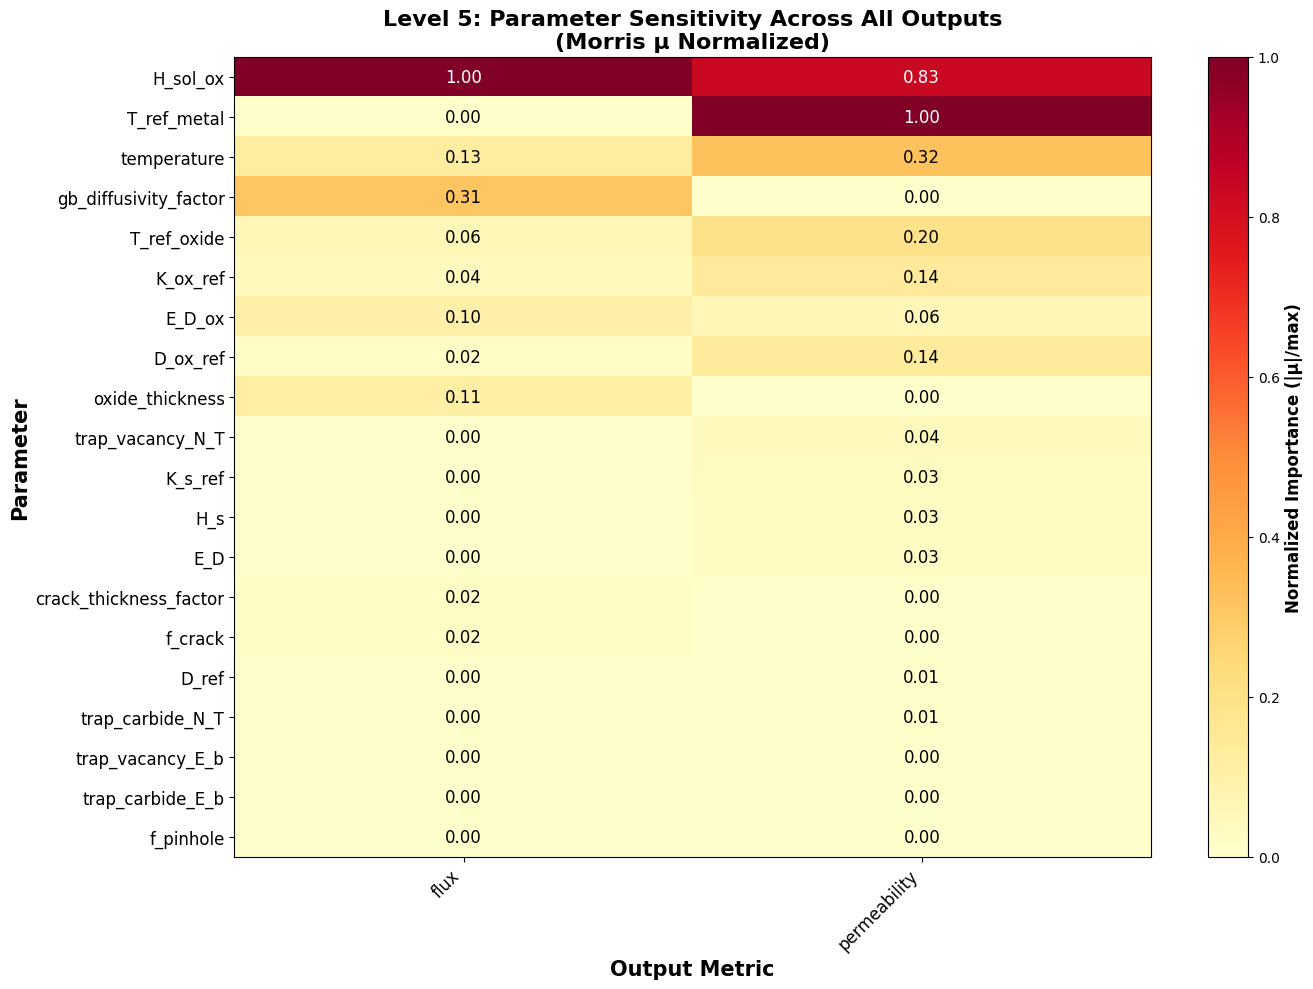

In [12]:
# =============================================================================
# HEATMAP: Parameter Importance Across All Outputs
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Get top 20 parameters for visualization
top_20 = df_all.head(20)

# Extract normalized values for heatmap
heatmap_data = top_20[[f'μ_{m}_norm' for m in VALID_OUTPUT_METRICS_L5]].values
param_labels = top_20['Parameter'].tolist()
output_labels = VALID_OUTPUT_METRICS_L5

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

# Labels
ax.set_xticks(np.arange(len(output_labels)))
ax.set_yticks(np.arange(len(param_labels)))
ax.set_xticklabels(output_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(param_labels, fontsize=12)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Importance (|μ|/max)', fontsize=12, fontweight='bold')

# Annotate cells with values
for i in range(len(param_labels)):
    for j in range(len(output_labels)):
        val = heatmap_data[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=12)

ax.set_title('Level 5: Parameter Sensitivity Across All Outputs\n(Morris μ Normalized)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Output Metric', fontsize=15, fontweight='bold')
ax.set_ylabel('Parameter', fontsize=15, fontweight='bold')

plt.tight_layout()


# Sobol Analysis


In [9]:
# =============================================================================
# CREATE FOCUSED RANGES FOR SOBOL (Top 10 from Morris Heatmap)
# =============================================================================

# top_10 already exists from the ranking cell above
SOBOL_FOCUSED_RANGES = {param: SUGGESTED_RANGES_LEVEL5[param] for param in top_10}

print("="*70)
print("FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)")
print("="*70)
for i, (param, bounds) in enumerate(SOBOL_FOCUSED_RANGES.items(), 1):
    importance = df_all[df_all['Parameter'] == param]['Avg_Importance'].values[0]
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]  (μ={importance:.3f})")
print("="*70)

FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)
   1. H_sol_ox                 : [2.00e+04, 1.70e+05]  (μ=0.917)
   2. T_ref_metal              : [6.00e+02, 1.40e+03]  (μ=0.500)
   3. temperature              : [5.73e+02, 1.27e+03]  (μ=0.223)
   4. gb_diffusivity_factor    : [1.00e+00, 1.00e+02]  (μ=0.156)
   5. T_ref_oxide              : [6.00e+02, 1.40e+03]  (μ=0.125)
   6. K_ox_ref                 : [8.00e-02, 4.00e-01]  (μ=0.091)
   7. E_D_ox                   : [6.90e+04, 7.10e+04]  (μ=0.080)
   8. D_ox_ref                 : [7.80e-21, 7.80e-17]  (μ=0.080)
   9. oxide_thickness          : [1.00e-10, 1.00e-05]  (μ=0.056)
  10. trap_vacancy_N_T         : [1.00e+24, 1.00e+28]  (μ=0.020)


In [10]:
# =============================================================================
# SOBOL ANALYSIS: TOP 10 PARAMETERS (from Morris screening)
# =============================================================================
# Set random seeds for reproducibility


sobol_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'#'*70}")
    print(f"# Running Sobol for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = sobol_sensitivity_level5(
        SOBOL_FOCUSED_RANGES,  # Use focused ranges from Morris top 10
        N_samples=1024,              # Samples (total = N × (2D + 2) = 22,528)
        output_metric=output_metric
        
        
    )
  
    sobol_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }

print("\n" + "="*70)
print("✓ Sobol analysis complete for all output metrics!")
print("="*70)


######################################################################
# Running Sobol for: flux
######################################################################

SOBOL SENSITIVITY ANALYSIS - LEVEL 5 (Complete Hierarchical Model)
Running 22528 Sobol samples (N_base=1024, 10 params)
Parameters: H_sol_ox, T_ref_metal, temperature, gb_diffusivity_factor, T_ref_oxide, K_ox_ref, E_D_ox, D_ox_ref, oxide_thickness, trap_vacancy_N_T
Output metric: flux
Second-order interactions: Yes
⏳ This may take a while...



/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1951: UserWarning: GB traps already in trap_list, not adding automatically
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 717.6 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 9.80e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 711.4 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.


  Completed 2252/22528 samples (10%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 613.7 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 7.29e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 3.19e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 832.4 K is outside data range 

  Completed 4504/22528 samples (20%)


...

  Completed 18016/22528 samples (80%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 4.31e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 4.55e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 3.02e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction 

  Completed 20268/22528 samples (90%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 7.82e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 2.31e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 2.02e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction 

  Completed 22520/22528 samples (100%)
  Completed 22528/22528 samples (100%)

✓ Sobol analysis complete
  Output range: [1.06e-14, 7.29e-02]
  Output span: 6884536499349.8× variation

  Parameter                       S1       ST    ST-S1
  ------------------------- -------- -------- --------
  T_ref_metal                  0.227    0.605    0.378
  temperature                  0.001    0.490    0.489
  H_sol_ox                     0.000    0.383    0.383
  T_ref_oxide                  0.003    0.195    0.192
  trap_vacancy_N_T             0.000    0.021    0.020
  K_ox_ref                     0.000    0.009    0.009
  oxide_thickness             -0.000    0.009    0.009
  D_ox_ref                    -0.000    0.002    0.002
  E_D_ox                      -0.000    0.000    0.000
  gb_diffusivity_factor       -0.000    0.000    0.000

  Sum(S1) = 0.231 (should be ~1 if additive)
  Sum(ST) = 1.714 (>1 indicates interactions)

  Top parameter interactions (S2 > 0.01):
    temperature × gb


OUTPUT: flux


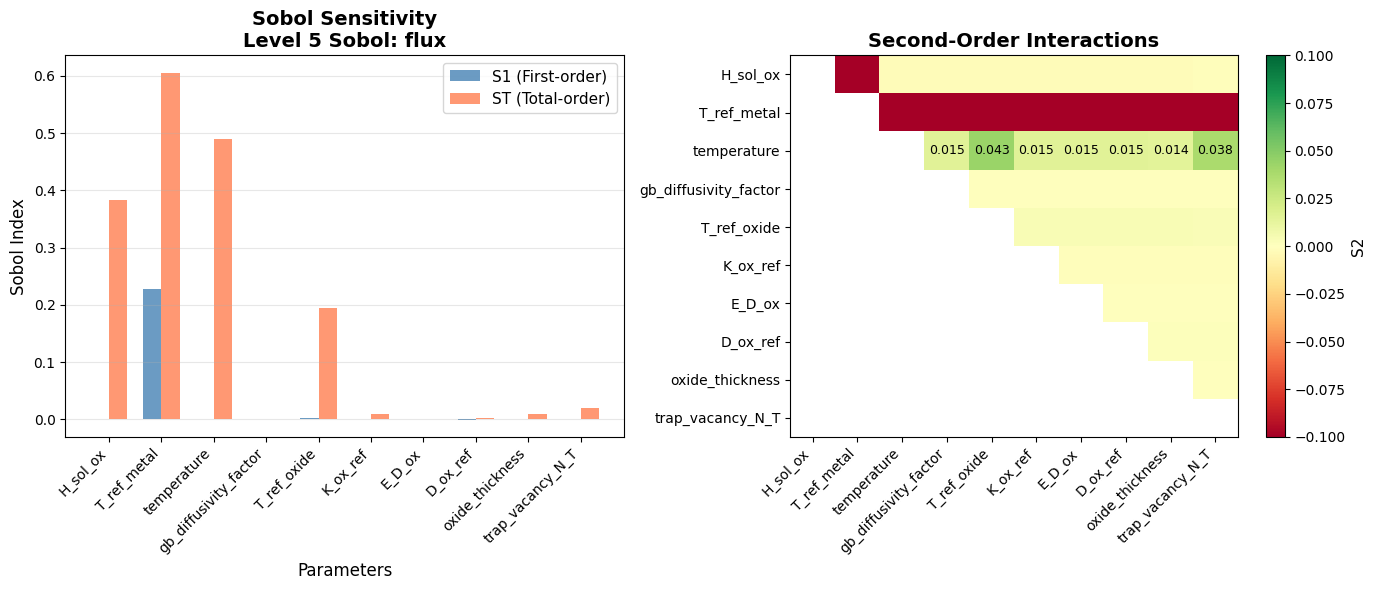


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: flux
            Parameter            S1  S1_conf           ST      ST_conf  Interactions
             H_sol_ox  2.143258e-04 0.013121 3.832837e-01 2.264552e+00  3.830694e-01
          T_ref_metal  2.269558e-01 0.529630 6.053157e-01 2.072159e+00  3.783599e-01
          temperature  8.065722e-04 0.011325 4.898950e-01 2.433795e+00  4.890884e-01
gb_diffusivity_factor -5.420566e-07 0.000006 7.858543e-08 5.239889e-07  6.206420e-07
          T_ref_oxide  3.030315e-03 0.007600 1.946148e-01 5.770382e-01  1.915844e-01
             K_ox_ref  2.789034e-04 0.001293 9.210892e-03 3.348358e-02  8.931989e-03
               E_D_ox -1.480074e-05 0.000051 2.256127e-05 7.459528e-05  3.736200e-05
             D_ox_ref -1.980688e-04 0.000800 2.102311e-03 7.622913e-03  2.300380e-03
      oxide_thickness -2.167659e-05 0.001452 8.819703e-03 2.573199e-02  8.841380e-03
     trap_vacancy_N_T  1.706286e-04 0.001942 2.052214e-02 6.016497e-02  2.035151e-02

Interpretation:

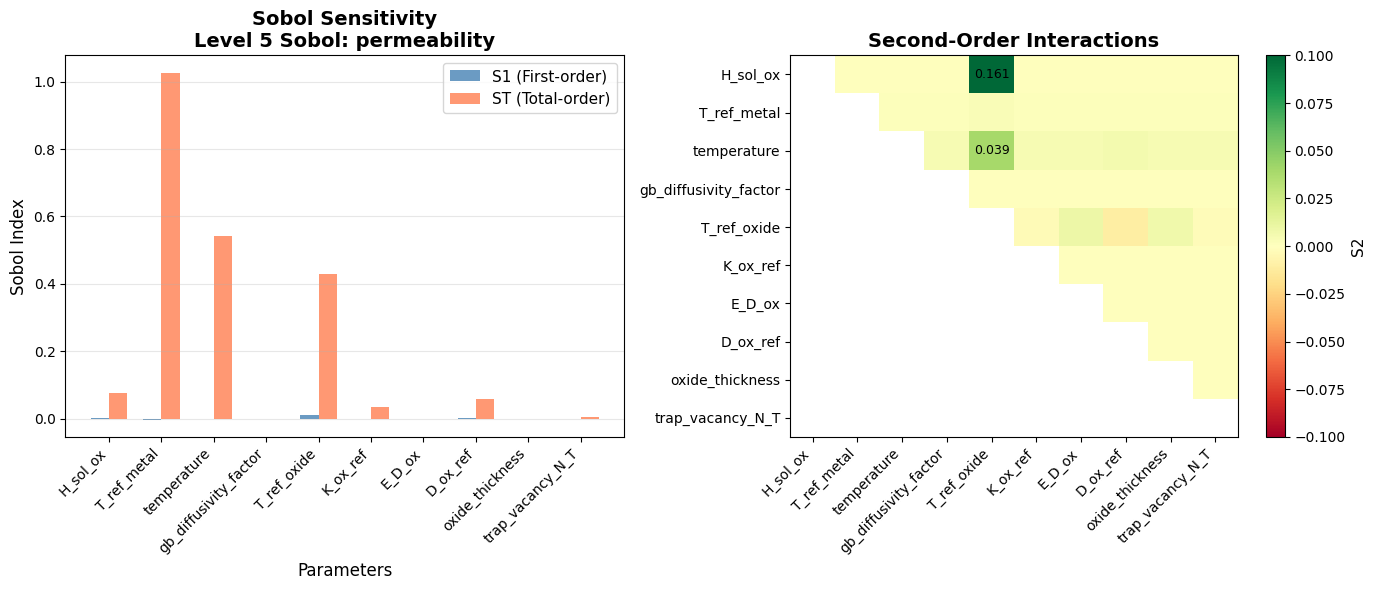


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: permeability
            Parameter        S1  S1_conf       ST  ST_conf  Interactions
             H_sol_ox  0.002079 0.015751 0.075480 0.432274      0.073400
          T_ref_metal -0.002975 0.022680 1.026808 6.768217      1.029783
          temperature -0.002011 0.015576 0.541211 3.185665      0.543222
gb_diffusivity_factor  0.000000 0.000000 0.000000 0.000000      0.000000
          T_ref_oxide  0.009623 0.102991 0.429210 4.421800      0.419587
             K_ox_ref -0.000160 0.003133 0.034126 0.208222      0.034286
               E_D_ox -0.000035 0.000246 0.000107 0.000814      0.000141
             D_ox_ref  0.000899 0.004180 0.058573 0.262683      0.057673
      oxide_thickness  0.000000 0.000000 0.000000 0.000000      0.000000
     trap_vacancy_N_T  0.000135 0.001324 0.004055 0.026676      0.003921

Interpretation:
  S1   : First-order effect (direct influence)
  ST   : Total-order effect (direct + interactions)
  ST-S1: Pure interactio

In [11]:
# =============================================================================
# PLOT SOBOL RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = sobol_results[output_metric]['Si']
    problem = sobol_results[output_metric]['problem']
    
    plot_sobol_results(Si, problem, f'Level 5 Sobol: {output_metric}')